In [10]:
#data cleaning

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
# Importing Walmart Dataset
df = pd.read_csv("Walmart_Sales.csv")

In [13]:
df.head(2)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106


In [14]:
#1.checking columns types 
df.dtypes


Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [15]:
# 2. Correcting Data Types
# Reason: 'Date' as an object prevents time-series analysis; 'Holiday_Flag' is logical.
df['Date']= pd.to_datetime(df['Date'],format='%d-%m-%Y')
df['Holiday_Flag']=df['Holiday_Flag'].astype('boolean')

In [16]:
#3. making sure that all columns have the correct datatype
df.dtypes

Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag           boolean
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [17]:
# 4. Handling Missing Values and Duplicates
# Reason: Missing data can bias results; duplicates lead to over-representation.
null_counts = df.isnull().sum()
duplicate_counts = df.duplicated().sum()
df = df.drop_duplicates()

In [18]:
# 5.checking for non reasonable values 
df.min()

Store                             1
Date            2010-02-05 00:00:00
Weekly_Sales              209986.25
Holiday_Flag                  False
Temperature                   -2.06
Fuel_Price                    2.472
CPI                         126.064
Unemployment                  3.879
dtype: object

In [19]:
# 6. checking for non reasonable values 
df.max()

Store                            45
Date            2012-10-26 00:00:00
Weekly_Sales             3818686.45
Holiday_Flag                   True
Temperature                  100.14
Fuel_Price                    4.468
CPI                      227.232807
Unemployment                 14.313
dtype: object

In [20]:
# 7. Outlier Management (IQR Method)
# Reason: Extreme values (like sales > $3.8M) can skew averages.
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] < lower) | (data[column] > upper)]

sales_outliers = detect_outliers(df, 'Weekly_Sales')


In [21]:
# 8. Feature Engineering for Analysis
# Reason: Extracting month/year allows for seasonal insight generation.
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

In [ ]:
#Visualization and Insights

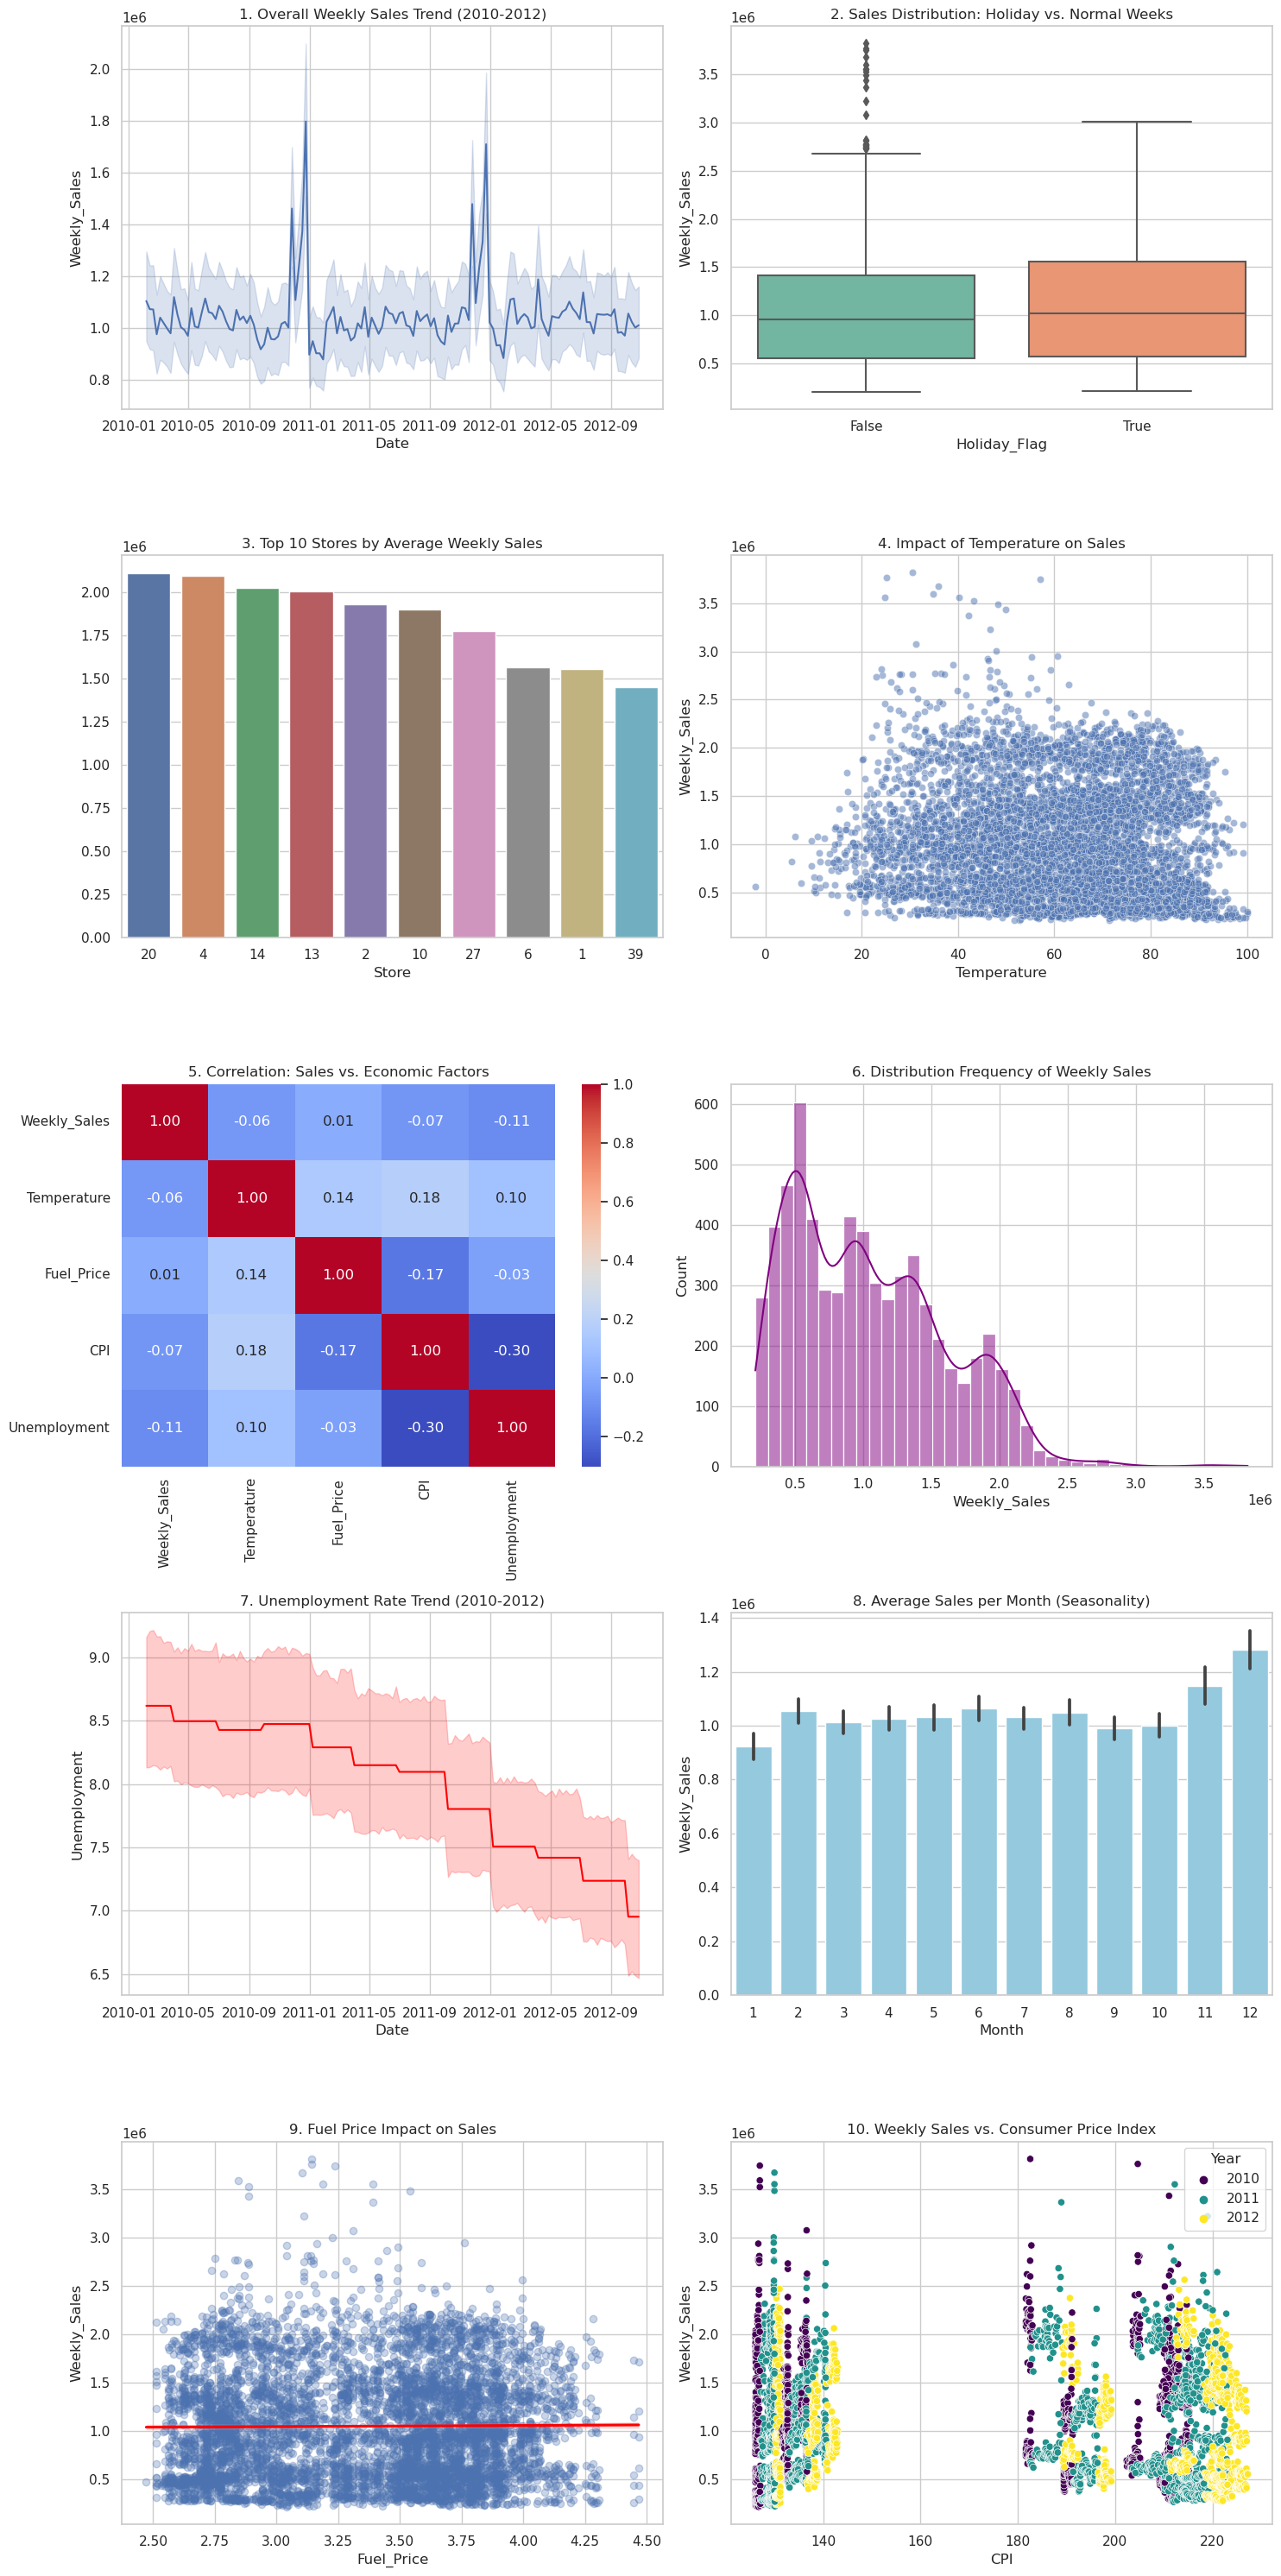

In [22]:
# Setting the aesthetic style of the plots
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 30))

# 1. Weekly Sales Trend
plt.subplot(5, 2, 1)
sns.lineplot(data=df, x='Date', y='Weekly_Sales')
plt.title('1. Overall Weekly Sales Trend (2010-2012)')

# 2. Holiday vs Non-Holiday Sales
plt.subplot(5, 2, 2)
sns.boxplot(data=df, x='Holiday_Flag', y='Weekly_Sales', palette='Set2')
plt.title('2. Sales Distribution: Holiday vs. Normal Weeks')

# 3. Top 10 Best Performing Stores
plt.subplot(5, 2, 3)
top_stores = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_stores.index, y=top_stores.values, order=top_stores.index)
plt.title('3. Top 10 Stores by Average Weekly Sales')

# 4. Sales vs. Temperature
plt.subplot(5, 2, 4)
sns.scatterplot(data=df, x='Temperature', y='Weekly_Sales', alpha=0.5)
plt.title('4. Impact of Temperature on Sales')

# 5. Correlation Heatmap
plt.subplot(5, 2, 5)
corr = df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('5. Correlation: Sales vs. Economic Factors')

# 6. Sales Distribution (Histogram)
plt.subplot(5, 2, 6)
sns.histplot(df['Weekly_Sales'], kde=True, color='purple')
plt.title('6. Distribution Frequency of Weekly Sales')

# 7. Unemployment Rate Over Time
plt.subplot(5, 2, 7)
sns.lineplot(data=df, x='Date', y='Unemployment', color='red')
plt.title('7. Unemployment Rate Trend (2010-2012)')

# 8. Monthly Seasonal Pattern
plt.subplot(5, 2, 8)
sns.barplot(data=df, x='Month', y='Weekly_Sales', color='skyblue')
plt.title('8. Average Sales per Month (Seasonality)')

# 9. Fuel Price vs. Sales
plt.subplot(5, 2, 9)
sns.regplot(data=df, x='Fuel_Price', y='Weekly_Sales', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('9. Fuel Price Impact on Sales')

# 10. Sales vs. CPI (Inflation)
plt.subplot(5, 2, 10)
sns.scatterplot(data=df, x='CPI', y='Weekly_Sales', hue='Year', palette='viridis')
plt.title('10. Weekly Sales vs. Consumer Price Index')

plt.tight_layout()
plt.show()

In [ ]:
### --- VISUALIZATION INSIGHTS (1-10) ---

# 1. Overall Weekly Sales Trend (2010-2012)
# Insight: Revenue is highly cyclical with massive spikes every November and December, 
# confirming that the holiday season is the primary driver of annual growth.

# 2. Sales Distribution: Holiday vs. Normal Weeks
# Insight: Holiday weeks exhibit significantly higher outliers and a wider sales range. 
# While median sales are stable, all record-breaking weeks occur during holidays.

# 3. Top 10 Best Performing Stores
# Insight: There is a major performance gap between locations; Store 20 and Store 4 
# significantly outperform others, averaging over $2M in weekly revenue.

# 4. Impact of Temperature on Sales
# Insight: The distribution is uniform across all temperatures, indicating that 
# Walmart's customer foot traffic is resilient to both extreme heat and cold.

# 5. Correlation: Sales vs. Economic Factors
# Insight: Correlation coefficients near zero prove that external factors like Fuel Price 
# and CPI have minimal impact compared to internal factors like store location.

# 6. Distribution Frequency of Weekly Sales
# Insight: The data is right-skewed; most weeks earn between $0.5M and $1.5M, 
# while a few elite "long tail" weeks reach up to $3.8M.

# 7. Unemployment Rate Trend (2010-2012)
# Insight: The steady downward trend in unemployment shows a recovering economy, 
# which provides a stable environment for consistent consumer spending.

# 8. Average Sales per Month (Seasonality)
# Insight: December is the highest-grossing month by a significant margin, 
# making it the most critical period for Walmart total annual revenue.

# 9. Fuel Price Impact on Sales
# Insight: A flat regression line shows that gas price fluctuations do not deter 
# customers, likely because Walmart provides essential goods that necessitate travel.

# 10. Weekly Sales vs. Consumer Price Index
# Insight: No linear relationship exists between inflation and sales volume. Despite 
# rising CPI, weekly sales maintained their established seasonal patterns.


# Final Summary of Insights:
# The Walmart sales analysis reveals that revenue is primarily driven by internal factors and 
# temporal cycles rather than external economic indicators. The most significant finding is 
# the extreme seasonality observed in the year-end holiday peaks and the December average sales, 
# which consistently outperform other months. Furthermore, the substantial performance gap 
# between the highest-grossing stores and the lowest suggests that location-specific variables
# such as regional management or population density are more critical to success than macro-trends 
# like fuel prices or inflation, which showed negligible correlation with sales. Ultimately, 
# the results indicate a resilient business model where consumer necessity and holiday traditions 
# maintain steady performance even amidst shifting economic conditions.
